In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score,ConfusionMatrixDisplay, precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [161]:
df = pd.read_csv('/content/sample_data/Chronic_Kidney_Dsease_data.csv')

In [162]:
df.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,...,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,...,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   int64  
 3   Ethnicity                      1659 non-null   int64  
 4   SocioeconomicStatus            1659 non-null   int64  
 5   EducationLevel                 1659 non-null   int64  
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   int64  
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   i

In [164]:
df.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
SocioeconomicStatus,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0


In [165]:
# Drop Non-Informative Columns
df = df.drop(["PatientID","DoctorInCharge"],axis = 1)

In [166]:
# Handle Missing Values
df = df.fillna(df.median(numeric_only=True))

In [167]:
df = df.fillna("Unknown")

In [168]:
le = LabelEncoder()

In [169]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

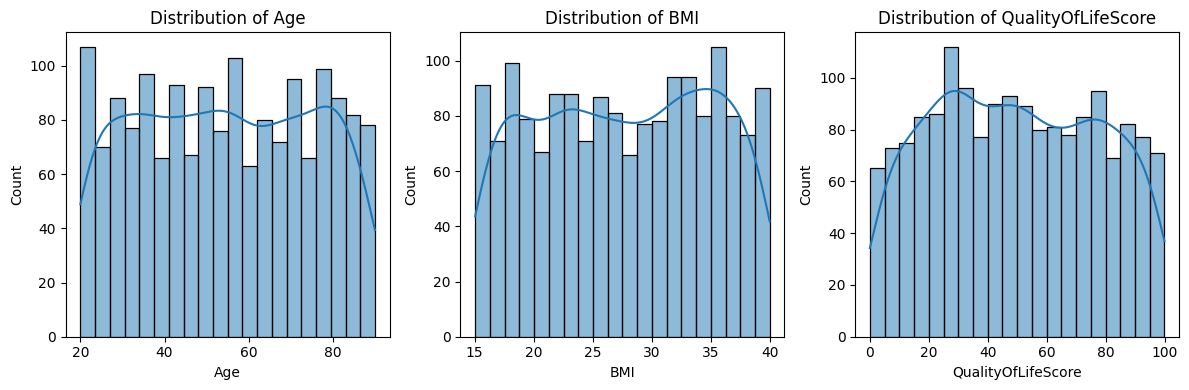

In [170]:
# Distribution Plots for Numeric Features
plt.figure(figsize=(12,4))
for i, col in enumerate(["Age", "BMI", "QualityOfLifeScore"]):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

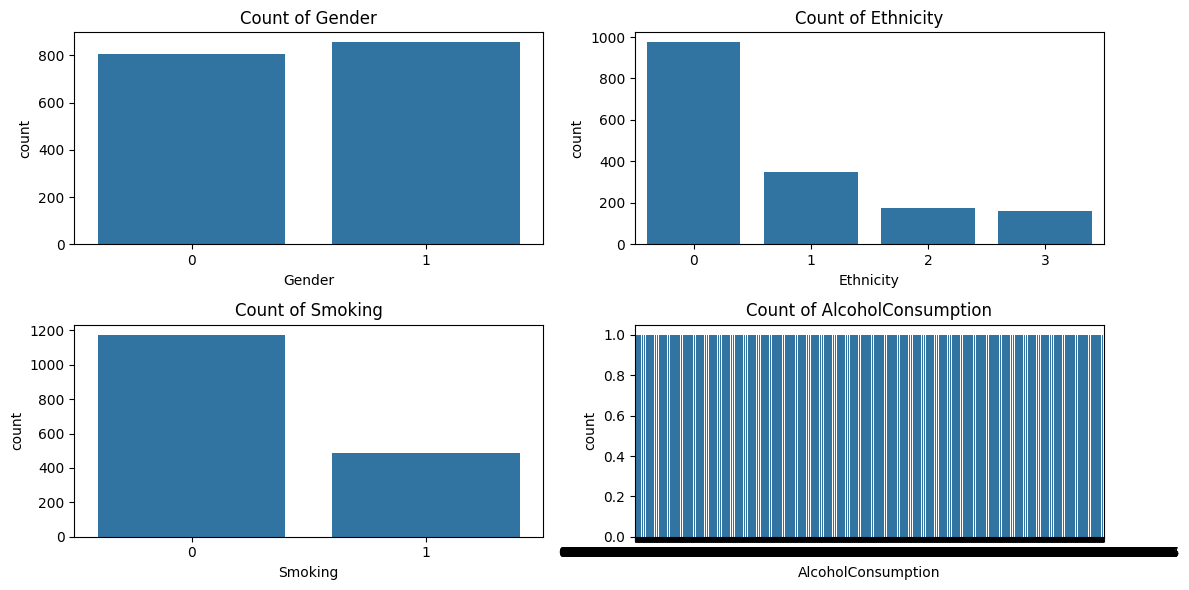

In [171]:
plt.figure(figsize=(12,6))
for i,col in enumerate(["Gender","Ethnicity","Smoking","AlcoholConsumption"]):
  plt.subplot(2,2,i+1)
  sns.countplot(x=df[col])
  plt.title(f"Count of {col}")
plt.tight_layout()
plt.show()

In [172]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus', 'EducationLevel',
       'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity',
       'DietQuality', 'SleepQuality', 'FamilyHistoryKidneyDisease',
       'FamilyHistoryHypertension', 'FamilyHistoryDiabetes',
       'PreviousAcuteKidneyInjury', 'UrinaryTractInfections', 'SystolicBP',
       'DiastolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine',
       'BUNLevels', 'GFR', 'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium',
       'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium',
       'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal',
       'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides',
       'ACEInhibitors', 'Diuretics', 'NSAIDsUse', 'Statins',
       'AntidiabeticMedications', 'Edema', 'FatigueLevels', 'NauseaVomiting',
       'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'HeavyMetalsExposure',
       'OccupationalExposureChemicals', 'WaterQuality',
       'Medi

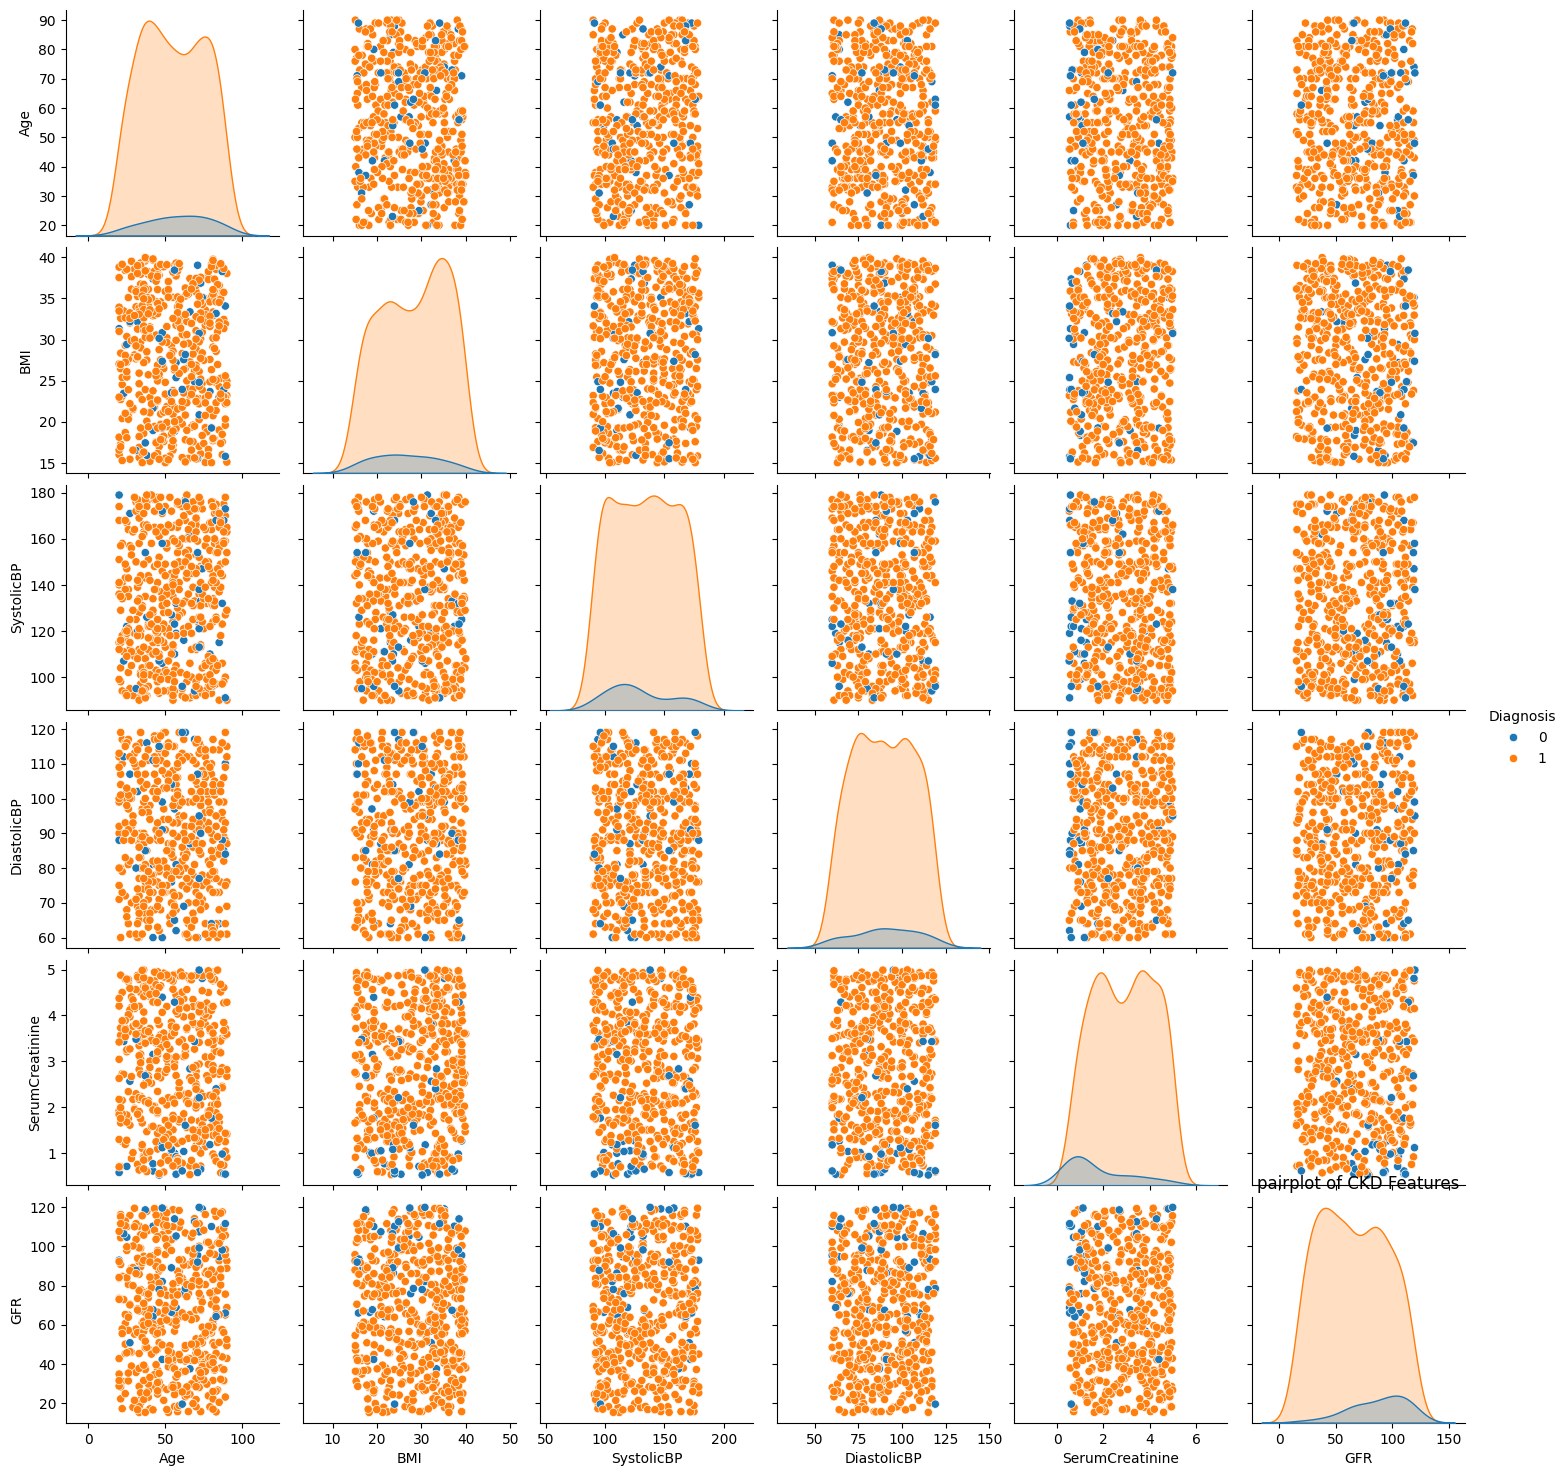

In [173]:
select = ['Age','BMI','SystolicBP','DiastolicBP','SerumCreatinine','GFR','Diagnosis']
sns.pairplot(df[select].sample(500),hue='Diagnosis')
plt.title("pairplot of CKD Features")
plt.show()

In [174]:
Selected_cols =  ['SystolicBP','DiastolicBP','FastingBloodSugar','HbA1c','SerumCreatinine','BUNLevels','GFR','ProteinInUrine',
                  'CholesterolTotal','CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides']

In [175]:
df_heatmap = df[Selected_cols]

In [176]:
correlation_matrix = df_heatmap.corr()

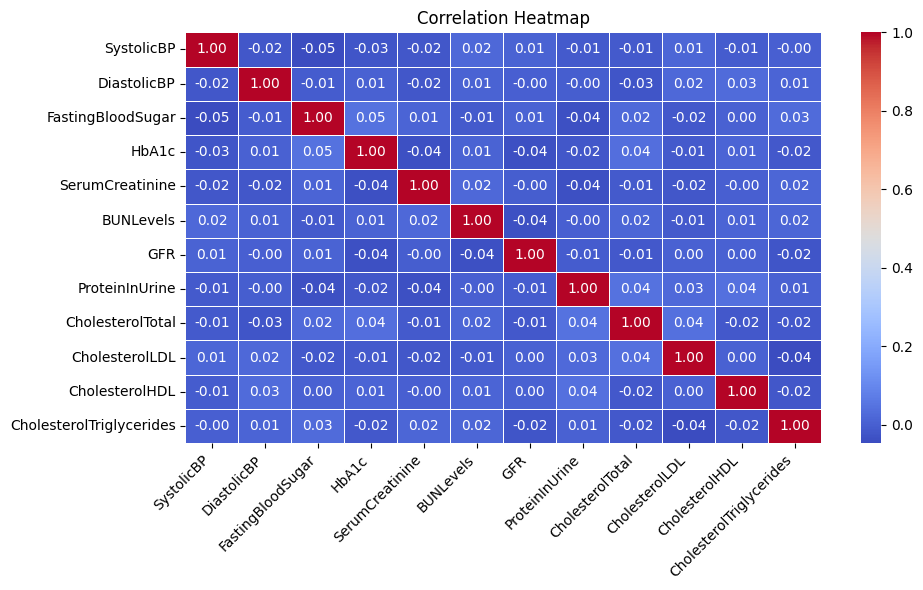

In [177]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt = ".2f", linewidths= .5)
plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [178]:
X = df.drop("Diagnosis",axis=1)
y = df["Diagnosis"]

In [179]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [180]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [181]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [182]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [183]:
y_pred = model.predict(X_test)

In [184]:
print(accuracy_score(y_test, y_pred))

0.9307228915662651


In [185]:
r2 = r2_score(y_test, y_pred)

In [186]:
print(r2_score(y_test, y_pred))

-0.03300865800865793


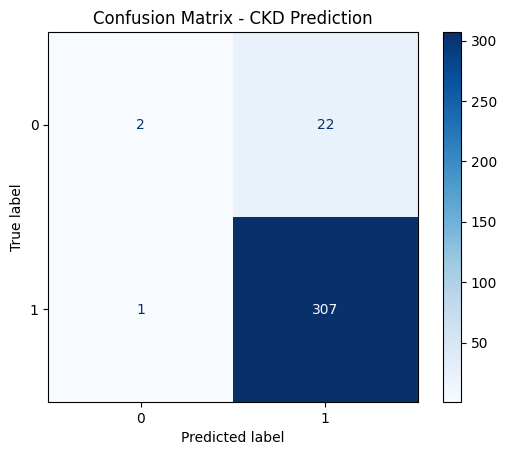

In [187]:
cm = confusion_matrix(y_test, y_pred)
dist = ConfusionMatrixDisplay(confusion_matrix=cm)
dist.plot(cmap="Blues")
plt.title("Confusion Matrix - CKD Prediction")
plt.show()

In [188]:
print(confusion_matrix(y_test,y_pred))

[[  2  22]
 [  1 307]]


In [189]:
y_true = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1])
y_pred = np.array([0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1])

In [190]:
print("True Labels:", y_true)
print("Predicted Labels:", y_pred)

True Labels: [0 1 0 1 0 1 0 1 0 0 1 1 0 1]
Predicted Labels: [0 0 0 1 0 1 1 1 0 0 1 0 0 1]


In [191]:
precision = precision_score(y_true, y_pred)
print(f"\nPrecision: {precision:.2f}")


Precision: 0.83


In [192]:
recall = recall_score(y_true, y_pred)
print(f"Recall: {recall:.2f}")

Recall: 0.71


In [193]:
f1 = f1_score(y_true, y_pred)
print(f"F1-Score: {f1:.2f}")

F1-Score: 0.77


In [195]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.86      0.80         7
           1       0.83      0.71      0.77         7

    accuracy                           0.79        14
   macro avg       0.79      0.79      0.78        14
weighted avg       0.79      0.79      0.78        14



In [ ]:
# Feature importance
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh', figsize=(8,6))
plt.title("Top 15 Important Features for CKD Prediction")
plt.show()
